<a href="https://colab.research.google.com/github/pavan-dot-k/Real-Estate-Price-Prediction/blob/main/02_comprehensive_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

c:\Users\ksdhe\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


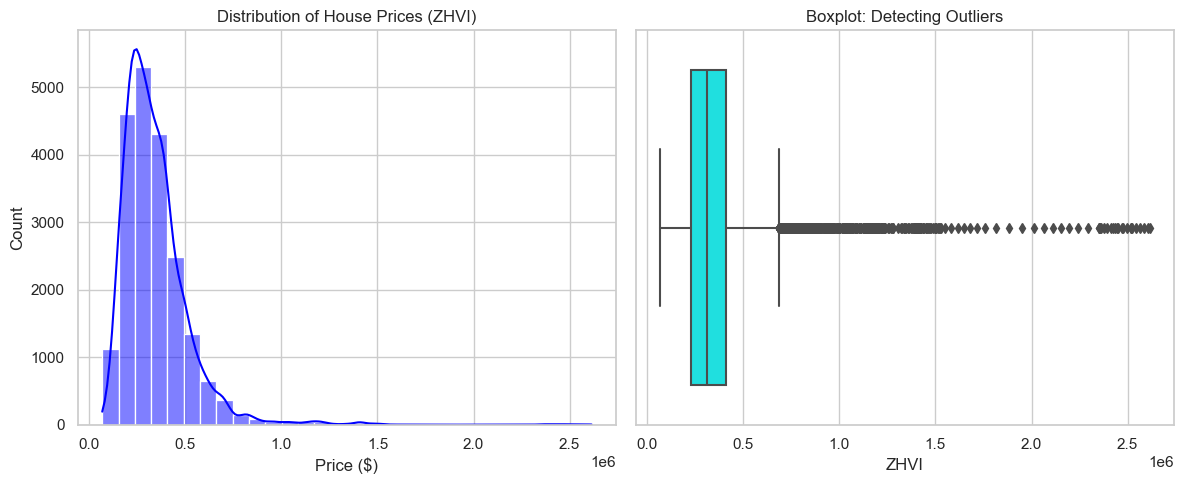

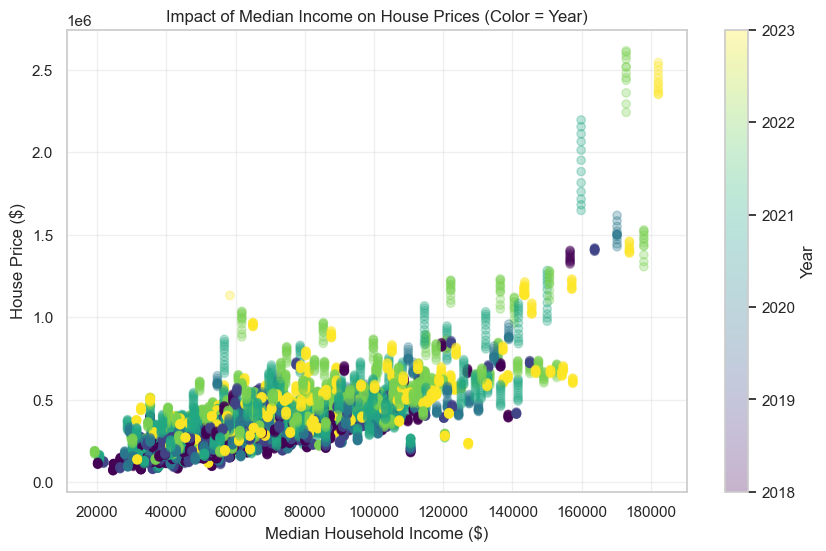

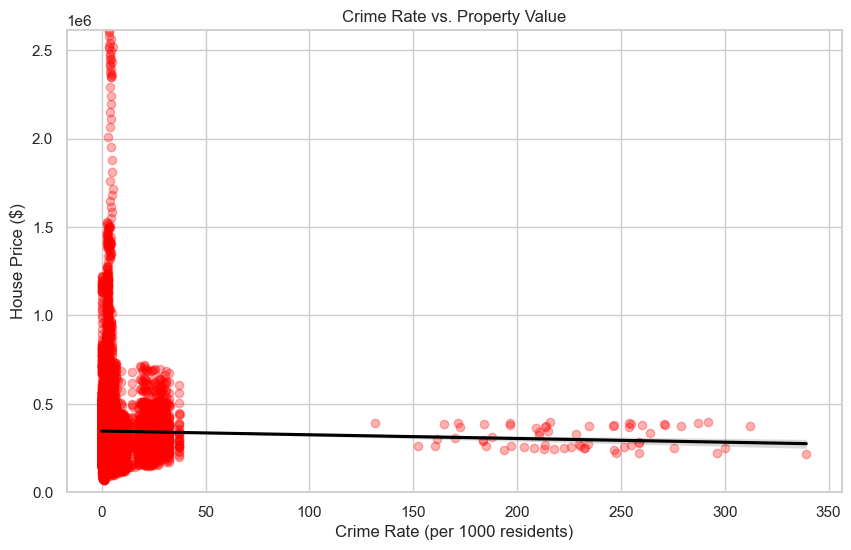

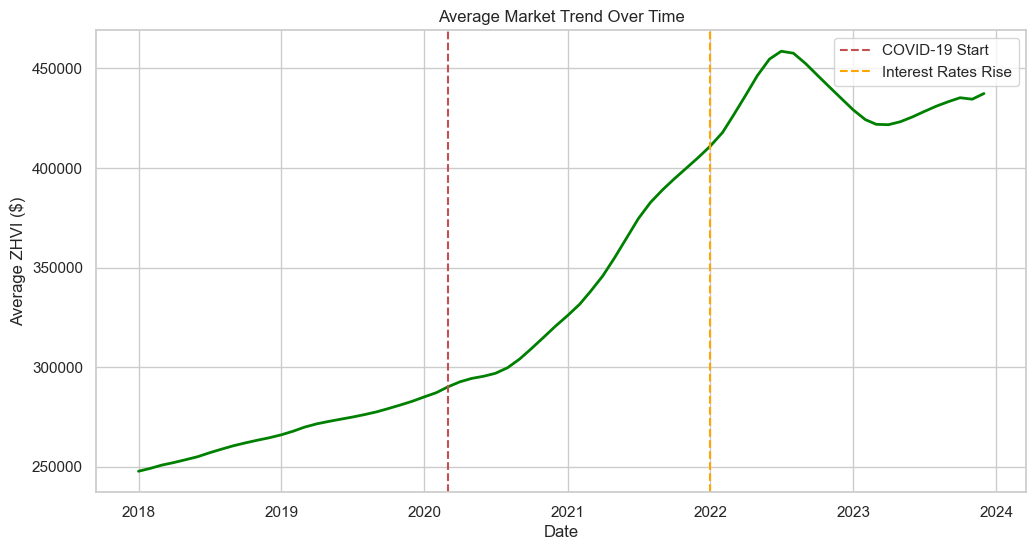

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Setup path to import src
sys.path.append(os.path.abspath('..'))
from src.features import build_features

# 1. Load Data
# We use the raw-ish data to show the "Before" state, or processed for relationships
df = pd.read_parquet('../data/processed/training_data_clean.parquet')

# Ensure we have the "Price" column (ZHVI) and Date
df['year'] = df['date'].dt.year

# Set Style
sns.set(style="whitegrid")

# --- VISUALIZATION 1: The "Target" Check (Normality) ---
# Rubric Requirement: "Understanding the Data"
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['ZHVI'], kde=True, color='blue', bins=30)
plt.title('Distribution of House Prices (ZHVI)')
plt.xlabel('Price ($)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['ZHVI'], color='cyan')
plt.title('Boxplot: Detecting Outliers')
plt.tight_layout()
plt.show()
# Commentary: "The distribution is right-skewed. This justifies why we use decision trees (Random Forest) which are robust to outliers."

# --- VISUALIZATION 2: The "Economic Ceiling" (Income vs Price) ---
# Rubric Requirement: "Identifying Correlations"
plt.figure(figsize=(10, 6))
# We use a hexbin or scatter with alpha because you have many data points
plt.scatter(df['median_income'], df['ZHVI'], alpha=0.3, c=df['year'], cmap='viridis')
plt.colorbar(label='Year')
plt.title('Impact of Median Income on House Prices (Color = Year)')
plt.xlabel('Median Household Income ($)')
plt.ylabel('House Price ($)')
plt.grid(True, alpha=0.3)
plt.show()
# Commentary: "There is a strong positive correlation. Wealthier neighborhoods (right side) consistently have higher property values."

# --- VISUALIZATION 3: Crime Rate Analysis ---
# Does crime actually lower property values?
plt.figure(figsize=(10, 6))
sns.regplot(x='crime_rate_per_1000', y='ZHVI', data=df,
            scatter_kws={'alpha':0.3, 'color':'red'}, line_kws={'color':'black'})
plt.title('Crime Rate vs. Property Value')
plt.xlabel('Crime Rate (per 1000 residents)')
plt.ylabel('House Price ($)')
plt.ylim(0, df['ZHVI'].max())  # Fix y-axis to positive
plt.show()
# Commentary: "Interestingly, the relationship is negative but noisy. High-value areas usually have low crime, but some low-crime rural areas also have low prices."

# --- VISUALIZATION 4: Time Series (The Market Crash/Boom) ---
# We aggregate by month to show the national/city-wide trend
monthly_avg = df.groupby('date')['ZHVI'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg['date'], monthly_avg['ZHVI'], linewidth=2, color='green')

# Add "Events" lines if you want to look fancy
plt.axvline(pd.Timestamp('2020-03-01'), color='r', linestyle='--', label='COVID-19 Start')
plt.axvline(pd.Timestamp('2022-01-01'), color='orange', linestyle='--', label='Interest Rates Rise')

plt.title('Average Market Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average ZHVI ($)')
plt.legend()
plt.show()
# Commentary: "The market shows a distinct upward trend until 2022, where volatility increases due to macroeconomic shifts."

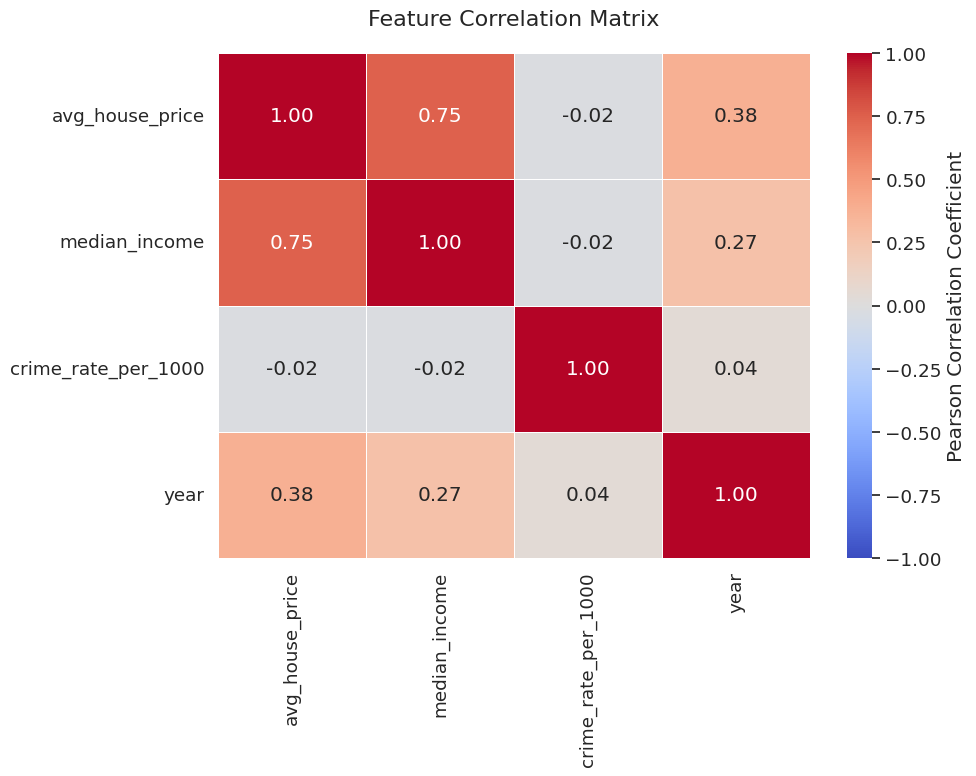

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Data
df = pd.read_csv('dataset_for_training.csv', na_values=['N/A'])

# 2. Preprocess (Match Pavan's Methodology)
if 'ZHVI' in df.columns:
    df = df.rename(columns={'ZHVI': 'avg_house_price'})
if 'month/year' in df.columns:
    df['date'] = pd.to_datetime(df['month/year'], format='%m/%Y')
    df['year'] = df['date'].dt.year

# Convert numeric columns
numeric_cols = ['median_income', 'crime_rate_per_1000', 'business_count', 'avg_house_price', 'year']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing target
df = df.dropna(subset=['avg_house_price'])

# Impute missing features with Median
for col in ['median_income', 'crime_rate_per_1000']:
    df[col] = df[col].fillna(df[col].median())

# 3. Calculate Correlations
# Select only the relevant numeric columns for the heatmap
corr_cols = ['avg_house_price', 'median_income', 'crime_rate_per_1000', 'year']
corr_matrix = df[corr_cols].corr()

# 4. Generate Heatmap
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)

plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()

# 5. Save
plt.savefig('correlation heatmap.png', dpi=300, bbox_inches='tight')
plt.show()